In [25]:
!pip install scikit-survival
import warnings
import pandas as pd
from sksurv.compare import compare_survival
from sksurv.linear_model import CoxPHSurvivalAnalysis
import arviz.preview as az
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import scipy as sp
import xarray as xr
from matplotlib import pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from statsmodels import datasets
from sksurv.datasets import load_whas500

In [26]:
!pip install lifelines
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter

In [27]:
X, y = load_whas500()
y_simplified = []
for i in range(len(y)):
    y_simplified.append(y[i][1])
y_simplified = np.array(y_simplified)
print(y_simplified)
X.head()

[2.178e+03 2.172e+03 2.190e+03 2.970e+02 2.131e+03 1.000e+00 2.122e+03
 1.496e+03 9.200e+02 2.175e+03 2.173e+03 1.671e+03 2.192e+03 8.650e+02
 2.166e+03 2.168e+03 9.050e+02 2.353e+03 2.146e+03 6.100e+01 2.358e+03
 2.114e+03 2.132e+03 2.139e+03 2.048e+03 2.152e+03 6.000e+00 2.156e+03
 1.180e+02 2.064e+03 8.490e+02 7.140e+02 2.057e+03 2.000e+00 7.000e+00
 2.151e+03 6.000e+00 4.220e+02 3.540e+02 2.065e+03 2.048e+03 1.065e+03
 5.350e+02 2.118e+03 9.700e+01 2.113e+03 1.000e+02 2.032e+03 1.317e+03
 2.126e+03 2.126e+03 2.123e+03 6.700e+02 3.430e+02 3.000e+00 2.009e+03
 6.400e+01 1.994e+03 1.579e+03 1.993e+03 2.000e+00 1.955e+03 4.200e+01
 1.964e+03 1.548e+03 4.460e+02 1.976e+03 2.009e+03 1.942e+03 1.000e+00
 1.510e+02 2.006e+03 2.086e+03 1.969e+03 1.939e+03 1.939e+03 1.940e+03
 1.576e+03 1.941e+03 1.970e+02 1.933e+03 9.500e+01 2.160e+03 2.084e+03
 2.145e+03 2.125e+03 1.920e+03 4.000e+00 1.553e+03 2.350e+02 1.920e+02
 1.233e+03 8.800e+01 1.954e+03 9.030e+02 6.120e+02 2.025e+03 2.000e+00
 7.000

,afb,age,av3,bmi,chf,cvd,diasbp,gender,hr,los,miord,mitype,sho,sysbp
0,1,83.0,0,25.54051,0,1,78.0,0,89.0,5.0,1,0,0,152.0
1,0,49.0,0,24.02398,0,1,60.0,0,84.0,5.0,0,1,0,120.0
2,0,70.0,0,22.14290,0,0,88.0,1,83.0,5.0,0,1,0,147.0
3,0,70.0,0,26.63187,1,1,76.0,0,65.0,10.0,0,1,0,123.0
4,0,70.0,0,24.41255,0,1,85.0,0,63.0,6.0,0,1,0,135.0


In [28]:
import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator
X['survival_times'] = y_simplified
female_data = X[X['gender'] == '0']
male_data = X[X['gender'] == '1']
print(len(female_data))
print(len(male_data))
rows_to_drop = female_data.sample(n=100)
female_data = female_data.drop(rows_to_drop.index)
len(female_data)
e_1 = female_data['survival_times']
e_2 = male_data['survival_times']
event_observed_A = y['fstat'][female_data.index]
event_observed_B = y['fstat'][male_data.index]
print(event_observed_A)
print(event_observed_B)
results = logrank_test(e_1, e_2, event_observed_A=event_observed_A, event_observed_B=event_observed_B)
print(results)

300
200
[False False  True False  True False False  True False False False  True
 False False False  True  True False False False False  True False False
 False  True False  True False False False  True False False  True False
 False  True  True  True  True  True  True  True  True  True  True False
  True  True False  True False  True False False False  True  True False
 False False  True False False  True False False  True  True  True False
  True  True False False False False False  True False False False False
 False  True  True False  True False False  True False False  True  True
 False  True False False False False False False  True False False False
  True False  True False False False False False  True  True False False
 False  True False  True  True  True  True False  True False False False
 False False  True False False False False False  True False False False
  True  True False  True False False False  True False False False False
 False False False  True  True False  True 

In [29]:
# Nick- Cox Model

# Test individual variables

from sksurv.compare import compare_survival
# Log Rank test for univariates
for col in ['afb','av3','chf','cvd','gender','miord','mitype','sho']:
    stat, p = compare_survival(y, X[col])
    print(f"{col.upper()}:")
    print(f"  Test statistic : {stat:.3f}")
    print(f"  p-value        : {p:.6f}")
# av3 is an imbalanced binary variable (only 11 non standard cases)
# av3 also fails log rank
# unlikely cox effect, even if significant: unstable effect from small n=11

AFB:
  Test statistic : 10.900
  p-value        : 0.000962
AV3:
  Test statistic : 1.524
  p-value        : 0.217076
CHF:
  Test statistic : 84.601
  p-value        : 0.000000
CVD:
  Test statistic : 2.861
  p-value        : 0.090724
GENDER:
  Test statistic : 7.791
  p-value        : 0.005250
MIORD:
  Test statistic : 9.571
  p-value        : 0.001977
MITYPE:
  Test statistic : 16.181
  p-value        : 0.000058
SHO:
  Test statistic : 23.836
  p-value        : 0.000001


In [30]:
# check proportionality and other interference
cols = ['afb','chf','cvd','gender','miord','mitype','sho',
            'age','bmi','diasbp','hr','sysbp','los']
df = X[cols].copy()
df["time"] = y["lenfol"]
df["event"] = y["fstat"]

cph = CoxPHFitter()
cph.fit(df, duration_col="time", event_col="event")

cph.check_assumptions(df, p_value_threshold=0.05)
# we find LOS does not meet PH assumptions. also it is data from post-outcome
# modelling survival on LOS (which is based on survival) is circular
# with LOS in the model we have evidence that sho and mitype should be stratified

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'mitype' failed the non-proportional test: p-value is 0.0418.

   Advice: with so few unique values (only 2), you can include `strata=['mitype', ...]` in the call
in `.fit`. See documentation in link [E] below.

2. Variable 'sho' failed the non-proportional test: p-value is 0.0051.

   Advice: with so few unique values (only 2), you can include `strata=['sho', ...]` in the call in
`.fit`. See documentation in link [E] below.

3. Variable 'los' failed the non-proportional test: p-value is 0.0090.

   Advice 1: the functional form of the variable 'los' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'los' using pd.cut, and then specify it in `strata=['los',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction t

[]

In [31]:
# establish significance of variables
cols_new = ['afb','chf','cvd','gender','miord','mitype','sho',
            'age','bmi','diasbp','hr','sysbp']
df = X[cols_new].copy()
df["time"] = y["lenfol"]
df["event"] = y["fstat"].astype(int)  # make explicit
# --- Step 1: baseline model
cph_base = CoxPHFitter()
cph_base.fit(df, duration_col="time", event_col="event")
cph_base.check_assumptions(df, p_value_threshold=0.05)
# --- Step 2: stratified model
cph_final = CoxPHFitter()
cph_final.fit(df, duration_col="time", event_col="event",
              strata=["sho","mitype"])
# --- Step 3: verify assumptions for stratified model
cph_final.check_assumptions(df, p_value_threshold=0.05)
# --- Step 4: results
cph_final.summary
# After removing LOS from the model we see sho is still suggested to be stratified, while mytype is borderline.
# we proceed by stratifying both
# Note that the CIs for afb, cvd, sysbp and miord all contain zero (the exp CIs contain 1)
# and their coefficients are near 0 (exp is near 1 ) hence we lack evidence of association

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'sho' failed the non-proportional test: p-value is 0.0179.

   Advice: with so few unique values (only 2), you can include `strata=['sho', ...]` in the call in
`.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



/usr/local/lib/python3.12/dist-packages/lifelines/fitters/__init__.py:1284: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, df_ in df.groupby(strata):
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, stratified_X in X.groupby(self.strata):
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

Proportional hazard assumption looks okay.


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
afb,0.050491,1.051787,0.175332,-0.293153,0.394135,0.745908,1.483101,0.0,0.287974,7.733667e-01,0.370775
chf,0.734638,2.084727,0.153442,0.433897,1.035379,1.543260,2.816173,0.0,4.787721,1.686858e-06,19.177230
cvd,-0.081187,0.922021,0.180257,-0.434485,0.272111,0.647598,1.312733,0.0,-0.450393,6.524268e-01,0.616112
gender,-0.309279,0.733976,0.149648,-0.602584,-0.015975,0.547395,0.984152,0.0,-2.066712,3.876126e-02,4.689241
miord,0.052741,1.054157,0.150454,-0.242144,0.347626,0.784943,1.415703,0.0,0.350546,7.259287e-01,0.462100
age,0.046479,1.047576,0.006849,0.033054,0.059903,1.033607,1.061734,0.0,6.785892,1.153715e-11,36.334922
bmi,-0.045052,0.955948,0.016705,-0.077793,-0.012311,0.925156,0.987765,0.0,-2.696898,6.998864e-03,7.158663
diasbp,-0.012333,0.987743,0.005013,-0.022159,-0.002507,0.978085,0.997496,0.0,-2.459978,1.389455e-02,6.169337
hr,0.011598,1.011665,0.003090,0.005542,0.017653,1.005558,1.017810,0.0,3.753751,1.742078e-04,12.486903


In [32]:
# Fit final model
cols_final = ['chf','gender','mitype','sho',
            'age','bmi','diasbp','hr']
df = X[cols_final].copy()
df["time"] = y["lenfol"]
df["event"] = y["fstat"].astype(int)  # make explicit
# --- Step 1: baseline model
cph_base = CoxPHFitter()
cph_base.fit(df, duration_col="time", event_col="event")
cph_base.check_assumptions(df, p_value_threshold=0.05)
# --- Step 2: stratified model
cph_final = CoxPHFitter()
cph_final.fit(df, duration_col="time", event_col="event",
              strata=["sho","mitype"])
# --- Step 3: verify assumptions for stratified model
cph_final.check_assumptions(df, p_value_threshold=0.05)
# --- Step 4: results
cph_final.summary

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'mitype' failed the non-proportional test: p-value is 0.0256.

   Advice: with so few unique values (only 2), you can include `strata=['mitype', ...]` in the call
in `.fit`. See documentation in link [E] below.

2. Variable 'sho' failed the non-proportional test: p-value is 0.0064.

   Advice: with so few unique values (only 2), you can include `strata=['sho', ...]` in the call in
`.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.

/usr/local/lib/python3.12/dist-packages/lifelines/fitters/__init__.py:1284: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, df_ in df.groupby(strata):
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, stratified_X in X.groupby(self.strata):
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

Proportional hazard assumption looks okay.


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
chf,0.740238,2.096434,0.150468,0.445327,1.035149,1.561000,2.815526,0.0,4.919580,8.673021e-07,20.136962
gender,-0.307209,0.735497,0.147195,-0.595705,-0.018712,0.551174,0.981462,0.0,-2.087090,3.688001e-02,4.761017
age,0.046691,1.047798,0.006759,0.033444,0.059938,1.034009,1.061771,0.0,6.908057,4.913350e-12,37.566430
bmi,-0.046138,0.954910,0.016553,-0.078581,-0.013694,0.924427,0.986399,0.0,-2.787269,5.315440e-03,7.555595
diasbp,-0.010993,0.989067,0.003604,-0.018056,-0.003931,0.982106,0.996077,0.0,-3.050723,2.282910e-03,8.774910
hr,0.011497,1.011563,0.002976,0.005664,0.017330,1.005680,1.017481,0.0,3.863065,1.119731e-04,13.124560


/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, stratified_X in X.groupby(self.strata):


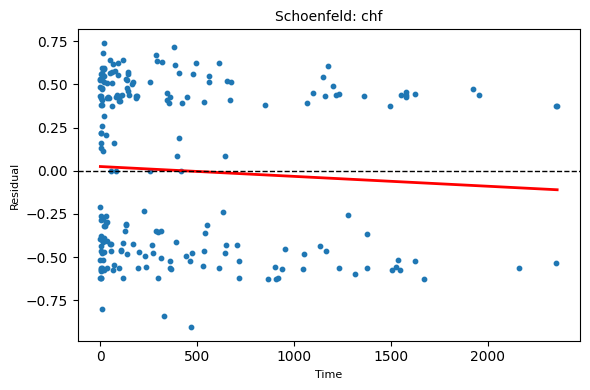

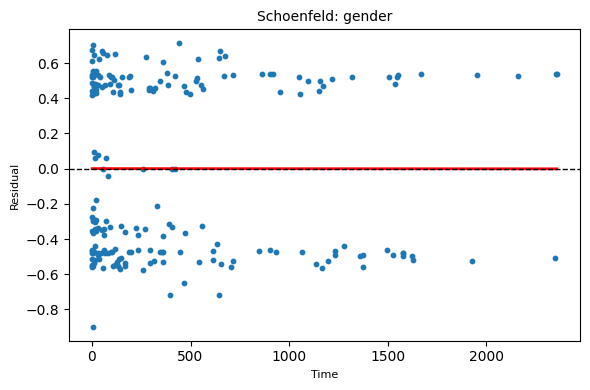

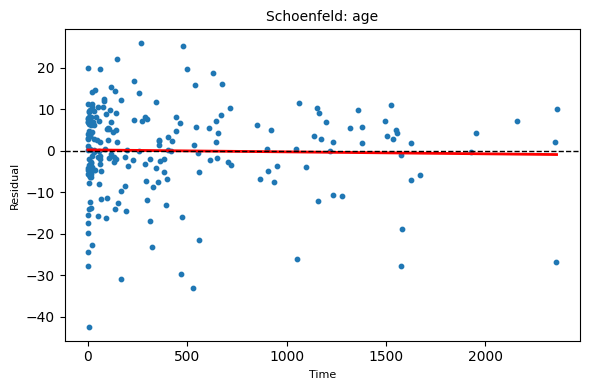

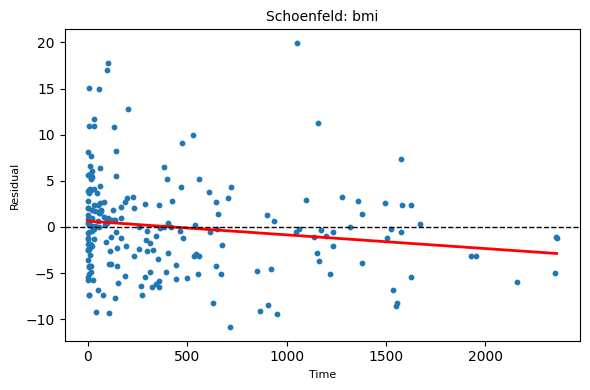

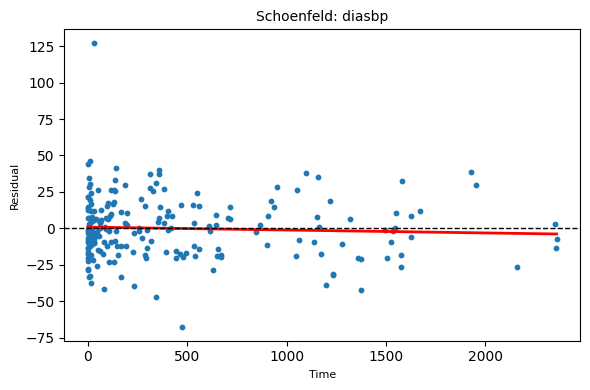

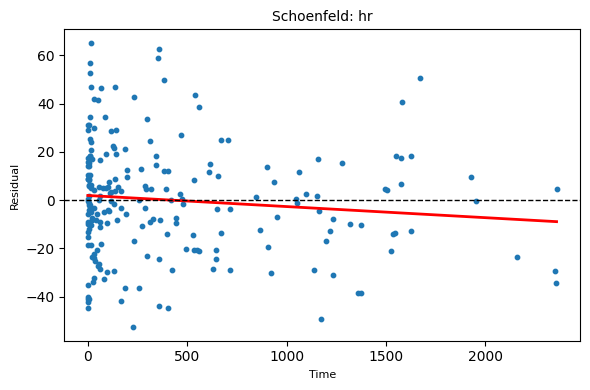

In [33]:
# diagnostics
resids = cph_final.compute_residuals(df, kind="schoenfeld")
event_times = df.loc[df["event"] == 1, "time"]

for col in resids.columns:
    x = event_times.values
    j = resids[col].values

    fig = plt.figure(figsize=(6,4))
    plt.scatter(x, j, s=10)

    coef = np.polyfit(x, j, 1)
    trend = np.poly1d(coef)

    order = np.argsort(x)
    plt.plot(x[order], trend(x)[order], color="red", linewidth=2)

    plt.axhline(0, linestyle="--", color="black", linewidth=1)

    plt.title(f"Schoenfeld: {col}", fontsize=10)
    plt.xlabel("Time", fontsize=8)
    plt.ylabel("Residual", fontsize=8)

    plt.tight_layout()

    fig.savefig(f"schoenfeld_{col}.png", dpi=100)
    plt.show()

In [34]:
# residual trends

df["log_hr"] = np.log(df["hr"])
df = df.drop(columns=["hr"])
df["log_bmi"] = np.log(df["bmi"])
df = df.drop(columns=["bmi"])
cph_last = CoxPHFitter()
cph_last.fit(df, duration_col="time", event_col="event",
              strata=["sho","mitype","chf"])
cph_last.check_assumptions(df, p_value_threshold=0.05)
# --- Step 4: results
cph_last.summary

/usr/local/lib/python3.12/dist-packages/lifelines/fitters/__init__.py:1284: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, df_ in df.groupby(strata):
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, stratified_X in X.groupby(self.strata):
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

Proportional hazard assumption looks okay.


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
gender,-0.358206,0.698929,0.149317,-0.650861,-0.065551,0.521596,0.936551,0.0,-2.398973,1.644114e-02,5.926546
age,0.046491,1.047589,0.006763,0.033235,0.059747,1.033794,1.061568,0.0,6.873905,6.246764e-12,37.220028
diasbp,-0.011395,0.988669,0.003621,-0.018493,-0.004298,0.981677,0.995712,0.0,-3.146702,1.651231e-03,9.242243
log_hr,1.106110,3.022577,0.283210,0.551027,1.661192,1.735035,5.265583,0.0,3.905611,9.398768e-05,13.377169
log_bmi,-1.356397,0.257587,0.404207,-2.148628,-0.564166,0.116644,0.568834,0.0,-3.355701,7.916424e-04,10.302863


/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, stratified_X in X.groupby(self.strata):


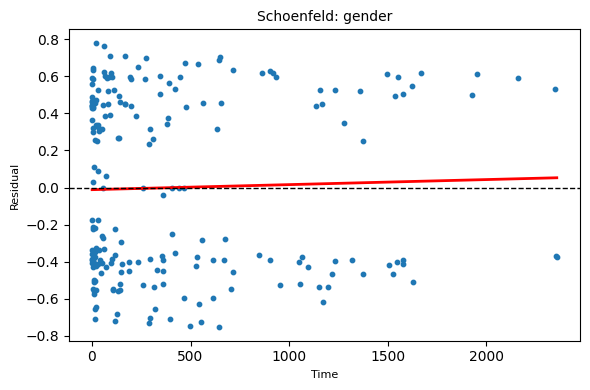

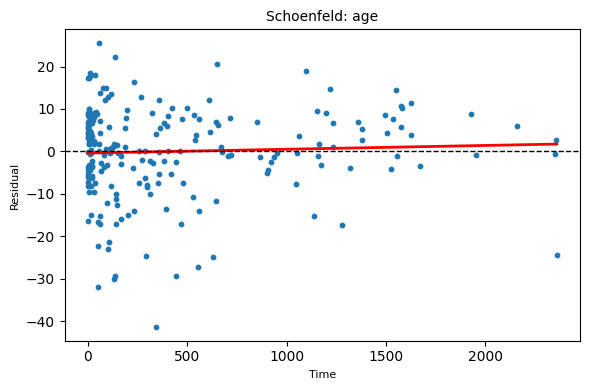

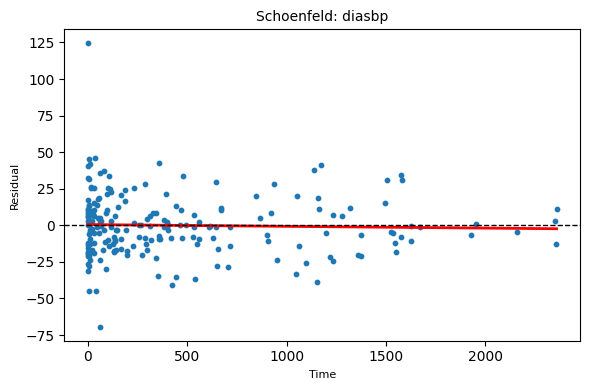

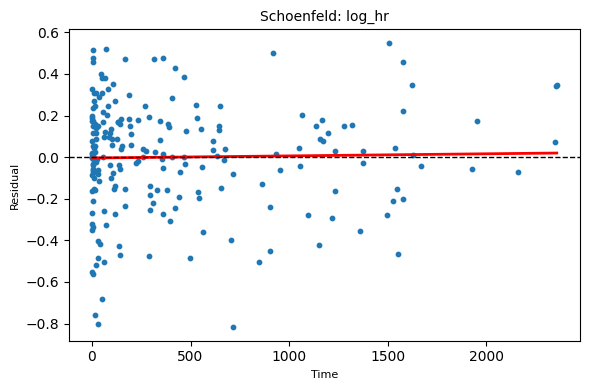

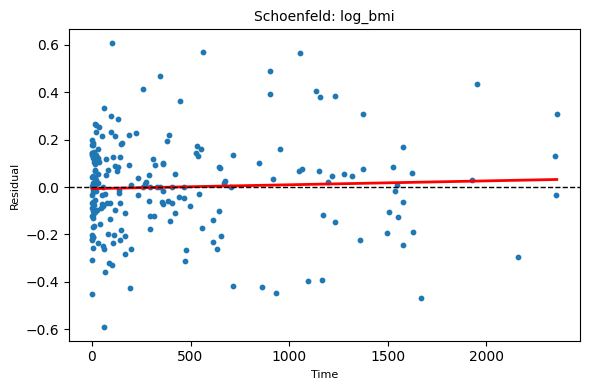

In [35]:
resids = cph_last.compute_residuals(df, kind="schoenfeld")
event_times = df.loc[df["event"] == 1, "time"]

for col in resids.columns:
    x = event_times.values
    j = resids[col].values

    fig = plt.figure(figsize=(6,4))
    plt.scatter(x, j, s=10)

    coef = np.polyfit(x, j, 1)
    trend = np.poly1d(coef)

    order = np.argsort(x)
    plt.plot(x[order], trend(x)[order], color="red", linewidth=2)

    plt.axhline(0, linestyle="--", color="black", linewidth=1)

    plt.title(f"Schoenfeld: {col}", fontsize=10)
    plt.xlabel("Time", fontsize=8)
    plt.ylabel("Residual", fontsize=8)

    plt.tight_layout()

    fig.savefig(f"schoenfeld_{col}.png", dpi=100)
    plt.show()

In [36]:
cph_last.params_

,coef
covariate,
gender,-0.358206
age,0.046491
diasbp,-0.011395
log_hr,1.106110
log_bmi,-1.356397


In [37]:
# base
cols = cph_last.params_.index.tolist()
base = df[cols].median(numeric_only=True)

base["gender"] = 0
# add strata (as strings!)
base["sho"] = '0'
base["mitype"] = '0'
base["chf"] = '0'

# profiles
patient_no_chf = base.copy()
patient_no_chf["chf"] = '0'

patient_chf = base.copy()
patient_chf["chf"] = '1'

Y = pd.DataFrame([patient_no_chf, patient_chf])

#  critical fix
Y[["sho","mitype","chf"]] = Y[["sho","mitype","chf"]].astype(str)

# predict
surv = cph_last.predict_survival_function(Y)


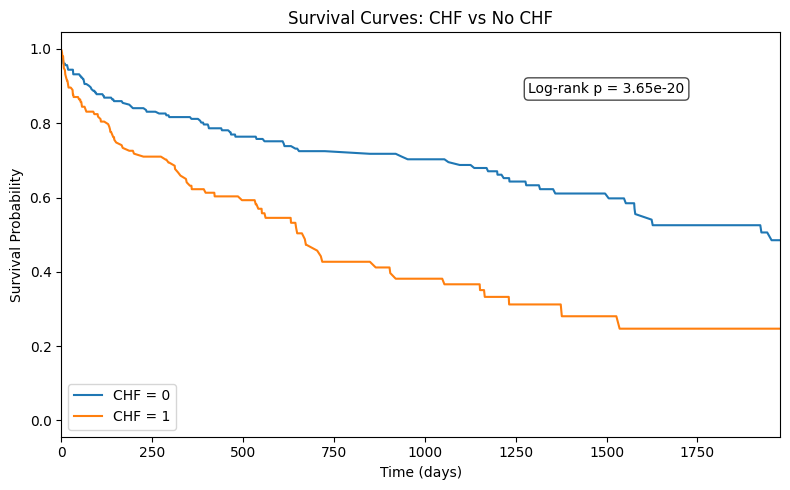

In [38]:
# ── CHF survival curves + log-rank test ──────────────────────────────────────
from lifelines.statistics import logrank_test

result = logrank_test(
    df_aft.loc[df_aft['chf'] == '0', 'time'],
    df_aft.loc[df_aft['chf'] == '1', 'time'],
    event_observed_A=df_aft.loc[df_aft['chf'] == '0', 'event'],
    event_observed_B=df_aft.loc[df_aft['chf'] == '1', 'event']
)

fig, ax = plt.subplots(figsize=(8, 5))

for i, label in enumerate(["CHF = 0", "CHF = 1"]):
    ax.plot(surv.index, surv.iloc[:, i], label=label)

ax.text(0.65, 0.85, f'Log-rank p = {result.p_value:.2e}',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax.set_xlim(0, df["time"].quantile(0.9))
ax.set_xlabel("Time (days)")
ax.set_ylabel("Survival Probability")
ax.set_title("Survival Curves: CHF vs No CHF")
ax.legend()
plt.tight_layout()
plt.show()

In [39]:
# ── Block 1: Weibull AFT ──────────────────────────────────────────────────────
# Unlike the final Cox model (which had to stratify CHF out due to PH violation),
# the Weibull AFT has no PH assumption — CHF enters directly as a covariate.

df_aft = X[['chf', 'gender', 'mitype', 'sho',
            'age', 'bmi', 'diasbp', 'hr']].copy()
df_aft["time"]  = y["lenfol"]
df_aft["event"] = y["fstat"].astype(int)

aft = WeibullAFTFitter()
aft.fit(df_aft, duration_col="time", event_col="event")
aft.summary

coef      exp(coef)  se(coef)  coef lower 95%  \
param   covariate                                                       
lambda_ age        -0.082229       0.921061  0.012522       -0.106772   
        bmi         0.084436       1.088103  0.029555        0.026510   
        chf        -1.354024       0.258199  0.268130       -1.879549   
        diasbp      0.020344       1.020553  0.006261        0.008074   
        gender      0.478171       1.613122  0.256180       -0.023932   
        hr         -0.021958       0.978281  0.005368       -0.032478   
        mitype      0.441430       1.554930  0.324981       -0.195520   
        sho        -2.350383       0.095333  0.481712       -3.294522   
        Intercept  12.549747  282023.776575  1.508679        9.592791   
rho_    Intercept  -0.590360       0.554128  0.058073       -0.704181   

                   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  \
param   covariate                                                             
lambda_ age             -0.057686             0.898730         9.439460e-01   
        bmi              0.142362             1.026865         1.152994e+00   
        chf             -0.828498             0.152659         4.367048e-01   
        diasbp           0.032615             1.008107         1.033153e+00   
        gender           0.980274             0.976352         2.665187e+00   
        hr              -0.011438             0.968043         9.886270e-01   
        mitype           1.078381             0.822407         2.939915e+00   
        sho             -1.406244             0.037086         2.450621e-01   
        Intercept       15.506702         14658.723143         5.425944e+06   
rho_    Intercept       -0.476540             0.494513         6.209282e-01   

                   cmp to          z             p   -log2(p)  
param   covariate                                              
lambda_ age           0.0  -6.566700  5.144245e-11  34.178250  
        bmi           0.0   2.856945  4.277406e-03   7.869048  
        chf           0.0  -5.049871  4.421074e-07  21.109100  
        diasbp        0.0   3.249588  1.155725e-03   9.756987  
        gender        0.0   1.866546  6.196508e-02   4.012401  
        hr            0.0  -4.090968  4.295756e-05  14.506729  
        mitype        0.0   1.358328  1.743596e-01   2.519862  
        sho           0.0  -4.879223  1.065044e-06  19.840655  
        Intercept     0.0   8.318370  8.918146e-17  53.316034  
rho_    Intercept     0.0 -10.165869  2.816003e-24  78.232625

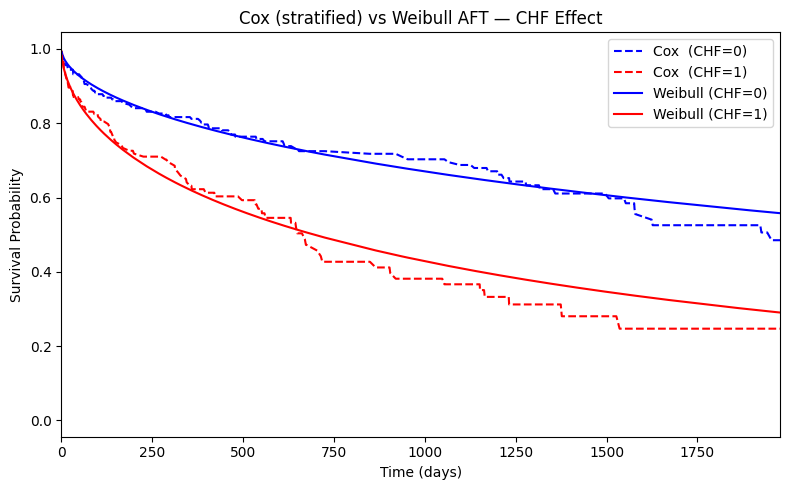

In [40]:
# ── Block 2: Cox vs Weibull — matched CHF profiles ───────────────────────────
# Build two patients identical at median covariates, differing only in CHF.
# df_aft (not df) because aft was fit on untransformed covariates.

base = df_aft.drop(columns=["time", "event"]).median(numeric_only=True)
base["gender"] = 0
base["mitype"] = "0"
base["sho"]    = "0"

p0 = base.copy(); p0["chf"] = 0
p1 = base.copy(); p1["chf"] = 1
Y  = pd.DataFrame([p0, p1])
Y[["chf", "mitype", "sho"]] = Y[["chf", "mitype", "sho"]].astype(str)

surv_cox = surv          # already computed above (CHF=0, CHF=1 profiles)
surv_aft = aft.predict_survival_function(Y)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(surv_cox.index, surv_cox.iloc[:, 0], 'b--', label='Cox  (CHF=0)')
ax.plot(surv_cox.index, surv_cox.iloc[:, 1], 'r--', label='Cox  (CHF=1)')
ax.plot(surv_aft.index, surv_aft.iloc[:, 0], 'b-',  label='Weibull (CHF=0)')
ax.plot(surv_aft.index, surv_aft.iloc[:, 1], 'r-',  label='Weibull (CHF=1)')

ax.set_xlim(0, df_aft["time"].quantile(0.9))
ax.set_xlabel("Time (days)")
ax.set_ylabel("Survival Probability")
ax.set_title("Cox (stratified) vs Weibull AFT — CHF Effect")
ax.legend()
plt.tight_layout()
plt.show()